In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset Shape:", X.shape)

Dataset Shape: (150, 4)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
svm = SVC()

svm.fit(X_train, y_train)

prediction = svm.predict(X_test)

print("Default Accuracy:", accuracy_score(y_test, prediction))

Default Accuracy: 1.0


In [6]:
parameters = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(
    estimator=SVC(),
    param_grid=parameters,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [7]:
print("Best Parameters:")

print(grid.best_params_)

print("Best Cross Validation Score:")

print(grid.best_score_)

Best Parameters:
{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best Cross Validation Score:
0.9583333333333334


In [8]:
best_model = grid.best_estimator_

prediction = best_model.predict(X_test)

print("GridSearch Accuracy:")

print(accuracy_score(y_test, prediction))

GridSearch Accuracy:
0.9666666666666667


In [9]:
random = RandomizedSearchCV(
    estimator=SVC(),
    param_distributions=parameters,
    n_iter=5,
    cv=5,
    random_state=42
)

random.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=SVC(), n_iter=5,
                   param_distributions={'C': [0.1, 1, 10, 100],
                                        'gamma': ['scale', 'auto'],
                                        'kernel': ['linear', 'rbf']},
                   random_state=42)

In [11]:
print("Random Search Best Parameters:")

print(random.best_params_)

Random Search Best Parameters:
{'kernel': 'linear', 'gamma': 'scale', 'C': 0.1}


In [12]:
random_model = random.best_estimator_

prediction = random_model.predict(X_test)

print("Random Search Accuracy:")

print(accuracy_score(y_test, prediction))

Random Search Accuracy:
1.0


In [13]:
comparison = pd.DataFrame({

    "Model":[
        "Default SVM",
        "GridSearchCV",
        "RandomSearchCV"
    ],

    "Accuracy":[
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, best_model.predict(X_test)),
        accuracy_score(y_test, random_model.predict(X_test))
    ]

})

print(comparison)

            Model  Accuracy
0     Default SVM  1.000000
1    GridSearchCV  0.966667
2  RandomSearchCV  1.000000


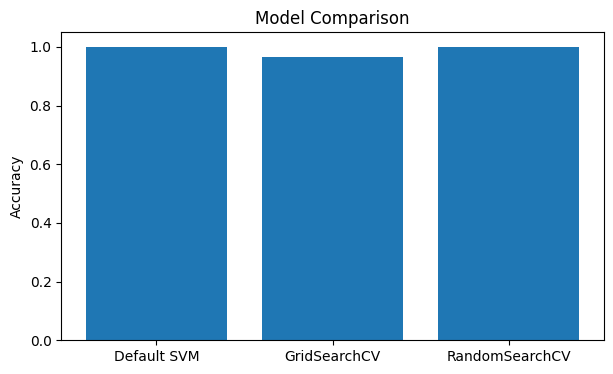

In [14]:
plt.figure(figsize=(7,4))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Comparison")

plt.ylabel("Accuracy")

plt.show()